# Cumulative Wave Power — Survey Date Analysis

**Author:** Chelsea Volpano  
**Email:** cvolpano@contractor.usgs.gov | cvolpano@gmail.com  
**Date:** 2026-06-24  
**Created using Claude Sonnet 4.6**

---

Standalone notebook — loads all data from scratch.  
Computes cumulative wave power (kWh/m) forward and backward from each survey
date using NDBC 44013, with thresholds at 200, 400, and 600 kWh/m.  
Overlays dimensionless fall velocity (Ω) on a secondary axis.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

%matplotlib inline

In [12]:
# ── Configuration ─────────────────────────────────────────────────────────────
OUT_DIR  = Path("wave_data")
PLOT_DIR = Path("wave_plots")
PLOT_DIR.mkdir(exist_ok=True)

START = "2024-10-01"
END   = "2025-03-31"

NDBC_44013_FILE = OUT_DIR / f"NDBC_44013_{START[:7]}_to_{END[:7]}.csv"
GRAIN_FILE      = OUT_DIR / "caco-waves_grainsize.csv"   # update path as needed

SURVEY_DATES     = ["2024-10-23", "2025-01-23", "2025-02-19", "2025-03-06"]
LOOKBACK_DAYS    = 21
LOOKFWD_DAYS     = 21
POWER_THRESHOLDS = [200, 400, 600]   # kWh/m

# Physical constants
RHO     = 1025.0   # seawater density (kg/m³)
G       = 9.81     # gravitational acceleration (m/s²)
RHO_S   = 2650.0   # sediment density (kg/m³)
NU      = 1.36e-6  # kinematic viscosity at ~10°C (m²/s)
P_CONST = (RHO * G**2) / (64 * np.pi) / 1000  # wave power constant → kW/m

# Spectral colormap
_sp = plt.colormaps["plasma"]
PALETTE = {
    "ndbc":    _sp(0.95),
    "wis":     _sp(0.08),
    "survey":  _sp(0.55),
    "insitu":  _sp(0.72),
}
THRESHOLD_COLORS = [_sp(0.75), _sp(0.45), _sp(0.08)]

## 1. Settling Velocity

In [13]:
def settling_velocity(d_m, rho_s=RHO_S, rho_w=RHO, nu=NU, g=G,
                      method="dietrich", SF=0.7, P=3.5):
    """
    Settling velocity (m/s) for grain diameter d_m (metres).
    Methods: 'soulsby', 'stokes', 'ferguson', 'dietrich'
    """
    s     = rho_s / rho_w
    Dstar = d_m * ((s - 1) * g / nu**2)**(1/3)

    if method == "soulsby":
        ws = (nu / d_m) * (np.sqrt(10.36**2 + 1.049 * Dstar**3) - 10.36)

    elif method == "stokes":
        ws = (s - 1) * g * d_m**2 / (18 * nu)

    elif method == "ferguson":
        C1, C2 = 18.0, 1.0
        ws = ((s - 1) * g * d_m**2) / (
            C1 * nu + (0.75 * C2 * (s - 1) * g * d_m**3)**0.5)

    elif method == "dietrich":
        R     = (s-1)          # submerged specific gravity
        Dstar = R * g * d_m**3 / nu**2           # dimensionless grain size (Different than others)
        logD  = np.log10(Dstar)

        R1 = (-3.76715
            + 1.92944 * logD
            - 0.09815 * logD**2
            - 0.00575 * logD**3
            + 0.00056 * logD**4)

        R2 = (np.log10(1.0 - (1 - SF) / 0.85)
            - (1.0 - SF)**2.3 * np.tanh(logD - 4.6)
            + 0.3 * (0.5 - SF) * (1.0 - SF)**2 * (logD - 4.6))

        R3 = (0.65 - (SF / 2.83) * np.tanh(logD - 4.6))**(1.0 + (3.5 - P) / 2.5)

        Wstar = R3 * 10**(R1 + R2)
        ws    = (Wstar * R * g * nu)**(1.0 / 3.0)

    else:
        raise ValueError(f"Unknown method '{method}'.")

    return ws

## 2. Load Grain Size & Compute ws

In [14]:
gs = pd.read_csv(GRAIN_FILE, encoding="latin1")
gs.columns = gs.columns.str.strip()

# Convert D50 from phi to metres
gs["D50_m"]  = 2**(-pd.to_numeric(gs["D50_PHI"], errors="coerce")) / 1000
gs["ws_ms"]  = gs["D50_m"].apply(lambda d: settling_velocity(d, method="soulsby"))
gs["ws_cms"] = gs["ws_ms"] * 100

# Mean ws used for Ω
ws_mean  = gs["ws_ms"].mean()
d50_mean = 250 #gs["D50_m"].mean()

print(f"Loaded {len(gs)} samples")
print(f"D50 range: {gs['D50_m'].min()*1e6:.1f} – {gs['D50_m'].max()*1e6:.1f} µm")
print(f"ws range:  {gs['ws_cms'].min():.3f} – {gs['ws_cms'].max():.3f} cm/s")
print(f"Mean D50:  {d50_mean*1e6:.1f} µm")
print(f"Mean ws:   {ws_mean*100:.3f} cm/s")

Loaded 6 samples
D50 range: 238.2 – 702.2 µm
ws range:  2.678 – 8.883 cm/s
Mean D50:  250000000.0 µm
Mean ws:   6.575 cm/s


## 3. Load NDBC 44013 & Compute Wave Power and Ω

In [15]:
def load_ndbc_csv(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "datetime"
    df = df.rename(columns={"WVHT": "Hs", "DPD": "Tp"})
    df = df.apply(pd.to_numeric, errors="coerce")
    df["Hs"] = df["Hs"].where(df["Hs"] < 99.0)
    df["Tp"] = df["Tp"].where(df["Tp"] < 99.0)
    df["P_kW_m"] = P_CONST * df["Hs"]**2 * df["Tp"]
    return df

ndbc_44013 = load_ndbc_csv(NDBC_44013_FILE)
ndbc_44013 = ndbc_44013.resample("1h").mean()  # hourly so cumsum = kWh/m
ndbc_44013["omega"] = ndbc_44013["Hs"] / (ws_mean * ndbc_44013["Tp"])

print(f"NDBC 44013 loaded: {len(ndbc_44013)} rows")
print(f"  {ndbc_44013.index.min()} → {ndbc_44013.index.max()}")
print(f"  ws_mean used for Ω: {ws_mean*100:.3f} cm/s")
ndbc_44013[["Hs", "Tp", "P_kW_m", "omega"]].describe().round(3)

NDBC 44013 loaded: 4368 rows
  2024-10-01 00:00:00 → 2025-03-31 23:00:00
  ws_mean used for Ω: 6.575 cm/s


,Hs,Tp,P_kW_m,omega
count,4353.000,4317.000,4317.000,4317.000
mean,0.991,6.389,4.194,2.758
std,0.513,2.966,5.657,1.373
min,0.195,2.060,0.068,0.336
25%,0.610,3.850,0.948,1.533
50%,0.885,5.410,2.056,2.827
75%,1.245,8.710,5.137,3.773
max,3.450,17.390,45.014,6.823


## 4. Compute Cumulative Wave Power Forward & Backward from Survey Dates

In [16]:
def cumulative_around(df, survey_date, lookback_days, lookfwd_days):
    """
    Compute cumulative wave power and Ω forward and backward from a survey date.
    Both segments start at cum_power=0 at the survey date.
    x axis is days from survey date (negative = before, positive = after).
    """
    t_survey = pd.Timestamp(survey_date)
    t0 = t_survey - pd.Timedelta(days=lookback_days)
    t1 = t_survey + pd.Timedelta(days=lookfwd_days)

    window = df.loc[t0:t1].copy()
    if window.empty:
        return None, None

    # Backward: slice up to survey date, reverse so index 0 = survey date,
    # cumsum accumulates going back in time, then negate days so x goes negative
    backward = window.loc[t0:t_survey].iloc[::-1].copy()
    backward["cum_power"] = backward["P_kW_m"].cumsum()
    backward["days"] = -((t_survey - backward.index).total_seconds() / 86400)

    # Forward: slice from survey date, cumsum accumulates going forward
    forward = window.loc[t_survey:t1].copy()
    forward["cum_power"] = forward["P_kW_m"].cumsum()
    forward["days"] = (forward.index - t_survey).total_seconds() / 86400

    return backward, forward

## 5. Plot — Cumulative Wave Power & Ω by Survey Date

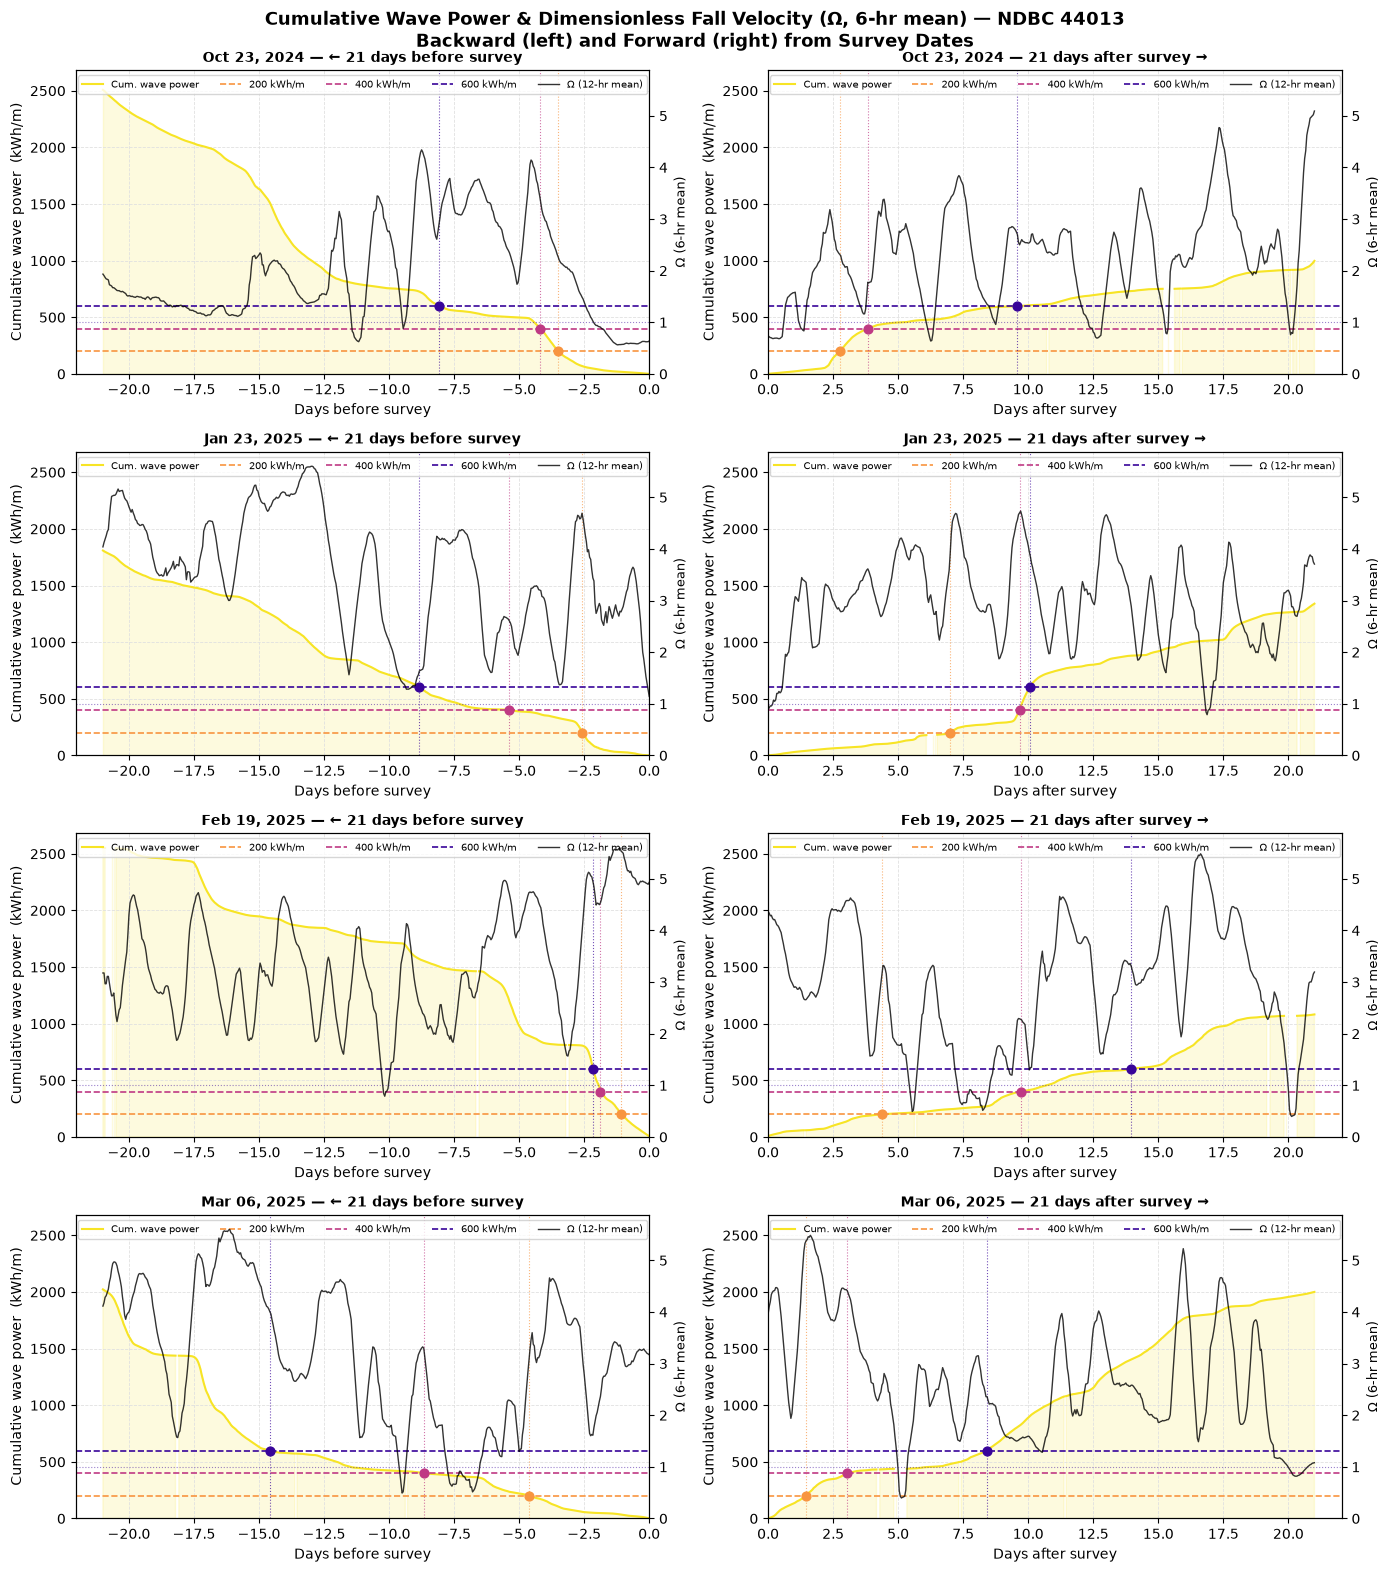

✓ Saved cumulative_wave_power_surveys.png


In [17]:
# Compute global y-axis limits across all surveys and directions
all_cum_power = []
all_omega     = []
for survey_date in SURVEY_DATES:
    bk, fw = cumulative_around(ndbc_44013, survey_date, LOOKBACK_DAYS, LOOKFWD_DAYS)
    for seg in [bk, fw]:
        if seg is not None:
            all_cum_power.append(seg["cum_power"].max())
            all_omega.append(seg["omega"].rolling(12, center=True, min_periods=1).mean().max())
ymax_power = max(all_cum_power) * 1.05
ymax_omega = max(all_omega) * 1.05

n_surveys = len(SURVEY_DATES)
fig, axes = plt.subplots(n_surveys, 2, figsize=(14, 4 * n_surveys))
fig.suptitle(
    "Cumulative Wave Power & Dimensionless Fall Velocity (Ω, 6-hr mean) — NDBC 44013\n"
    "Backward (left) and Forward (right) from Survey Dates",
    fontsize=13, fontweight="bold"
)

for i, survey_date in enumerate(SURVEY_DATES):
    backward, forward = cumulative_around(
        ndbc_44013, survey_date, LOOKBACK_DAYS, LOOKFWD_DAYS)
    if backward is None:
        print(f"  ⚠ No data around {survey_date}")
        continue

    t_survey = pd.Timestamp(survey_date)

    for j, (seg_label, df_seg, xlabel) in enumerate([
        (f"← {LOOKBACK_DAYS} days before survey", backward, "Days before survey"),
        (f"{LOOKFWD_DAYS} days after survey →",   forward,  "Days after survey"),
    ]):
        ax  = axes[i, j]
        ax2 = ax.twinx()

        x = df_seg["days"]

        # ── Cumulative wave power ─────────────────────────────────────────────
        ax.fill_between(x, df_seg["cum_power"], alpha=0.15, color=PALETTE["ndbc"])
        ax.plot(x, df_seg["cum_power"], color=PALETTE["ndbc"], lw=1.5,
                label="Cum. wave power")

        # Threshold lines and crossing markers
        for thresh, tcol in zip(POWER_THRESHOLDS, THRESHOLD_COLORS):
            ax.axhline(thresh, color=tcol, lw=1.2, ls="--", label=f"{thresh} kWh/m")
            crossed = df_seg[df_seg["cum_power"] >= thresh]
            if not crossed.empty:
                x_cross = crossed["days"].iloc[0]
                ax.axvline(x_cross, color=tcol, lw=0.8, ls=":", alpha=0.7)
                ax.scatter(x_cross, thresh, color=tcol, s=40, zorder=5)

        # ── 6-hour rolling mean of Omega on secondary axis ────────────────────
        omega_smooth = df_seg["omega"].rolling(12, center=True, min_periods=1).mean()
        ax2.plot(x, omega_smooth, color='black', lw=1,
                 alpha=0.8, label="Ω (12-hr mean)")
        ax2.axhline(1, color=PALETTE["wis"], lw=0.8, ls=":", alpha=0.5)
        ax2.axhline(6, color=PALETTE["wis"], lw=0.8, ls=":", alpha=0.5)
        ax2.set_ylabel("Ω (6-hr mean)", color="black", fontsize=9)
        ax2.tick_params(axis="y", labelcolor="black")
        ax2.set_ylim(0, ymax_omega)

        ax.set_title(f"{t_survey.strftime('%b %d, %Y')} — {seg_label}",
                     fontweight="bold", fontsize=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Cumulative wave power  (kWh/m)")
        ax.set_ylim(0, ymax_power)
        ax.set_xlim(right=0) if j == 0 else ax.set_xlim(left=0)
        ax.grid(color="#e0e0e0", linewidth=0.6, linestyle="--")

        # Combined legend
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2,
                  fontsize=7.5, loc="upper center", ncol=5)

fig.tight_layout()
fig.savefig(PLOT_DIR / "cumulative_wave_power_surveys.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved cumulative_wave_power_surveys.png")

## 6. Summary Table — Days to Reach Each Power Threshold

In [18]:
print(f"{'Survey':<15} {'Direction':<10} "
      + "".join(f"{'Days to '+str(t)+' kWh/m':>20}" for t in POWER_THRESHOLDS))
print("-" * (25 + 20 * len(POWER_THRESHOLDS)))

for survey_date in SURVEY_DATES:
    backward, forward = cumulative_around(
        ndbc_44013, survey_date, LOOKBACK_DAYS, LOOKFWD_DAYS)
    if backward is None:
        continue
    t_survey = pd.Timestamp(survey_date)

    for seg_label, df_seg in [("backward", backward), ("forward", forward)]:
        row_str = f"  {t_survey.strftime('%Y-%m-%d'):<13} {seg_label:<10}"
        for thresh in POWER_THRESHOLDS:
            crossed = df_seg[df_seg["cum_power"] >= thresh]
            if not crossed.empty:
                days = abs((crossed.index[0] - t_survey).total_seconds() / 86400)
                row_str += f"  {days:>18.1f}d"
            else:
                row_str += f"  {'> '+str(LOOKBACK_DAYS)+'d':>18}"
        print(row_str)

Survey          Direction     Days to 200 kWh/m   Days to 400 kWh/m   Days to 600 kWh/m
-------------------------------------------------------------------------------------
  2024-10-23    backward                   3.5d                 4.2d                 8.1d
  2024-10-23    forward                    2.8d                 3.8d                 9.6d
  2025-01-23    backward                   2.6d                 5.4d                 8.8d
  2025-01-23    forward                    7.0d                 9.7d                10.1d
  2025-02-19    backward                   1.1d                 1.9d                 2.2d
  2025-02-19    forward                    4.4d                 9.7d                14.0d
  2025-03-06    backward                   4.6d                 8.7d                14.6d
  2025-03-06    forward                    1.5d                 3.0d                 8.4d


In [19]:
# ── Save threshold crossing summary to CSV ────────────────────────────────────
# One row per survey × direction × threshold combination.
# Columns: survey_date, direction, threshold_kWh_m, days_to_threshold,
#          datetime_crossed, mean_omega_6hr, mean_Hs, mean_Tp

threshold_records = []

for survey_date in SURVEY_DATES:
    backward, forward = cumulative_around(
        ndbc_44013, survey_date, LOOKBACK_DAYS, LOOKFWD_DAYS)
    if backward is None:
        print(f"  ⚠ No data around {survey_date} — skipping.")
        continue

    for direction, df_seg in [("backward", backward), ("forward", forward)]:
        df_seg = df_seg.copy()
        df_seg["omega_6hr"] = df_seg["omega"].rolling(6, center=True, min_periods=1).mean()

        for thresh in POWER_THRESHOLDS:
            crossed = df_seg[df_seg["cum_power"] >= thresh]
            if not crossed.empty:
                days_to   = abs(crossed["days"].iloc[0])
                dt_cross  = crossed.index[0]
                # Mean conditions over the window up to threshold crossing
                window    = df_seg.loc[:dt_cross]
                mean_omega = window["omega_6hr"].mean()
                mean_Hs    = window["Hs"].mean()
                mean_Tp    = window["Tp"].mean()
            else:
                days_to    = np.nan
                dt_cross   = pd.NaT
                mean_omega = np.nan
                mean_Hs    = np.nan
                mean_Tp    = np.nan

            threshold_records.append({
                "survey_date":       survey_date,
                "direction":         direction,
                "threshold_kWh_m":   thresh,
                "days_to_threshold": days_to,
                "datetime_crossed":  dt_cross,
                "mean_omega_6hr":    round(mean_omega, 3) if not np.isnan(mean_omega) else np.nan,
                "mean_Hs_m":         round(mean_Hs, 3)    if not np.isnan(mean_Hs)    else np.nan,
                "mean_Tp_s":         round(mean_Tp, 3)    if not np.isnan(mean_Tp)    else np.nan,
            })

threshold_df = pd.DataFrame(threshold_records)

out_path = OUT_DIR / f"cumulative_power_thresholds_{START}-{END}.csv"
threshold_df.to_csv(out_path, index=False)
print(f"✓ Saved {len(threshold_df)} rows → {out_path}")
print()
print(threshold_df.to_string(index=False))

✓ Saved 24 rows → wave_data\cumulative_power_thresholds_2024-10-01-2025-03-31.csv

survey_date direction  threshold_kWh_m  days_to_threshold    datetime_crossed  mean_omega_6hr  mean_Hs_m  mean_Tp_s
 2024-10-23  backward              200           3.500000 2024-10-19 12:00:00           1.080      0.655      9.349
 2024-10-23  backward              400           4.208333 2024-10-18 19:00:00           1.368      0.818      9.275
 2024-10-23  backward              600           8.083333 2024-10-14 22:00:00           2.224      0.841      6.852
 2024-10-23   forward              200           2.750000 2024-10-25 18:00:00           1.655      0.747      7.888
 2024-10-23   forward              400           3.833333 2024-10-26 20:00:00           1.654      0.866      8.796
 2024-10-23   forward              600           9.583333 2024-11-01 14:00:00           2.058      0.771      6.760
 2025-01-23  backward              200           2.583333 2025-01-20 10:00:00           2.970      0.954 

In [20]:
# ── Save cumulative wave power data to CSV ────────────────────────────────────
# Saves one row per hourly timestep per survey/direction combination.
# Columns: survey_date, direction, datetime, days, Hs, Tp, P_kW_m,
#          omega, omega_6hr, cum_power

records = []

for survey_date in SURVEY_DATES:
    backward, forward = cumulative_around(
        ndbc_44013, survey_date, LOOKBACK_DAYS, LOOKFWD_DAYS)
    if backward is None:
        print(f"  ⚠ No data around {survey_date} — skipping.")
        continue

    for direction, df_seg in [("backward", backward), ("forward", forward)]:
        df_out = df_seg[["days", "Hs", "Tp", "P_kW_m", "omega", "cum_power"]].copy()
        df_out["omega_6hr"]    = df_out["omega"].rolling(6, center=True, min_periods=1).mean()
        df_out["survey_date"]  = survey_date
        df_out["direction"]    = direction
        df_out["datetime"]     = df_out.index
        df_out = df_out.reset_index(drop=True)
        df_out = df_out[["survey_date", "direction", "datetime", "days",
                          "Hs", "Tp", "P_kW_m", "omega", "omega_6hr", "cum_power"]]
        records.append(df_out)

cum_power_df = pd.concat(records, ignore_index=True)

out_path = OUT_DIR / f"cumulative_wave_power_{START}-{END}.csv"
cum_power_df.to_csv(out_path, index=False)
print(f"✓ Saved {len(cum_power_df)} rows → {out_path}")
print(f"\nColumns: {list(cum_power_df.columns)}")
cum_power_df.head(10)

✓ Saved 4040 rows → wave_data\cumulative_wave_power_2024-10-01-2025-03-31.csv

Columns: ['survey_date', 'direction', 'datetime', 'days', 'Hs', 'Tp', 'P_kW_m', 'omega', 'omega_6hr', 'cum_power']


,survey_date,direction,datetime,days,Hs,Tp,P_kW_m,omega,omega_6hr,cum_power
0,2024-10-23,backward,2024-10-23 00:00:00,-0.000000,0.460,9.090,0.944097,0.769648,0.702698,0.944097
1,2024-10-23,backward,2024-10-22 23:00:00,-0.041667,0.435,9.545,0.884248,0.693125,0.688618,1.828346
2,2024-10-23,backward,2024-10-22 22:00:00,-0.083333,0.405,9.545,0.767313,0.645323,0.671045,2.595659
3,2024-10-23,backward,2024-10-22 21:00:00,-0.125000,0.425,10.000,0.889222,0.646379,0.638902,3.484881
4,2024-10-23,backward,2024-10-22 20:00:00,-0.166667,0.395,10.000,0.765589,0.600752,0.599547,4.250470
5,2024-10-23,backward,2024-10-22 19:00:00,-0.208333,0.360,11.450,0.728019,0.478184,0.588924,4.978489
6,2024-10-23,backward,2024-10-22 18:00:00,-0.250000,0.365,10.405,0.679482,0.533518,0.581253,5.657971
7,2024-10-23,backward,2024-10-22 17:00:00,-0.291667,0.395,9.545,0.731637,0.629389,0.587716,6.389607
8,2024-10-23,backward,2024-10-22 16:00:00,-0.333333,0.410,10.405,0.863408,0.599294,0.595269,7.253016
9,2024-10-23,backward,2024-10-22 15:00:00,-0.375000,0.430,9.545,0.865854,0.685158,0.621607,8.118870
